In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [49]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [50]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [51]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [52]:
df.shape

(19402, 4)

In [53]:
df.dtypes

entity                  object
code                    object
year                     int64
fertility_rate_hist    float64
dtype: object

In [54]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [55]:
mexico = df[(df["entity"] == "Mexico")]

In [56]:
mexico.head(3)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731


In [57]:
japon = df[(df["entity"] == "Japan")]

In [58]:
japon.head(3)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373


In [59]:
type(df["entity"])

pandas.core.series.Series

In [60]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [61]:
type(tasa_mexico)
type(anios_mexico)
type(anios_japon)
type(tasa_japon)

numpy.ndarray

In [62]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

In [63]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)

minimo_japon = np.min(tasa_japon)
desvicion_japon = np.std(tasa_japon)

In [64]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

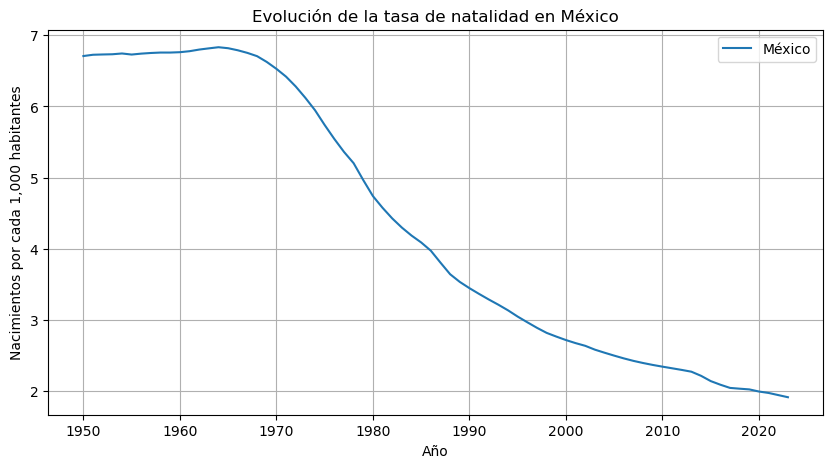

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México",
)

plt.title("Evolución de la tasa de natalidad en México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

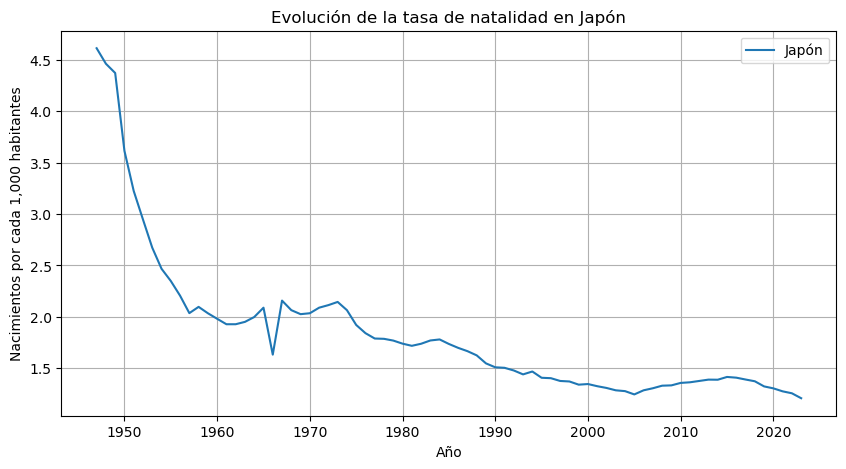

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón",
)

plt.title("Evolución de la tasa de natalidad en Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

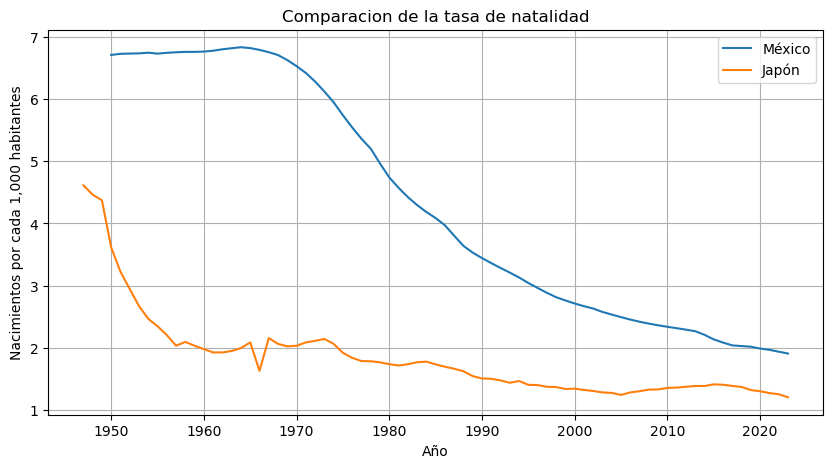

In [67]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México",
)
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.title("Comparacion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()
plt.show()

In [68]:
#Mascara Filtro
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [69]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [70]:
anios_japon = anios_japon[mascara_coincidencia_anios]
len(anios_japon)

74

In [71]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [72]:
anios_japon

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [73]:
diferencia = tasa_mexico - tasa_japon
diferencia_mx_jp = tasa_mexico - tasa_japon

In [74]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

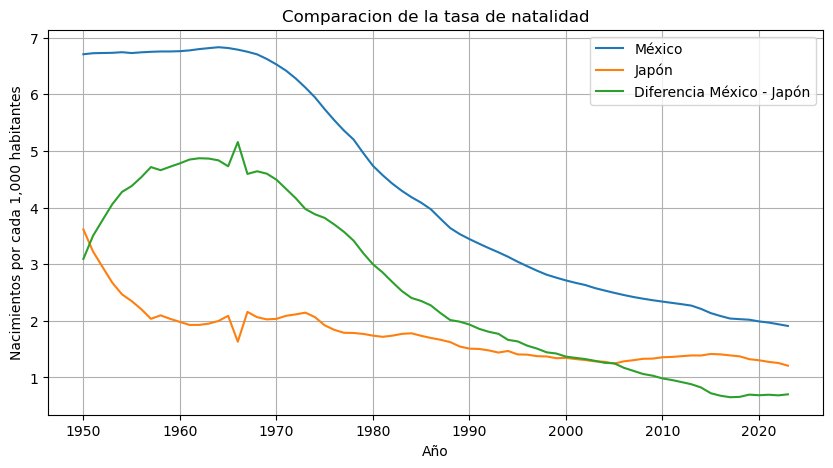

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México",
)
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label="Diferencia México - Japón"
)
plt.title("Comparacion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()
plt.show()

In [76]:
anios_comunes = np.intersect1d(anios_mexico, anios_japon)

In [77]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [79]:
len(anios_comunes)

74

In [78]:
#otra forma de filtrsar los datos es con merge:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [80]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947
